In [ ]:
# Step 1, download the data
import yfinance as yf
import pandas as pd
import numpy as np

sp500 = yf.download('^GSPC', start='2000-01-01', end='2025-04-12')
sp500.to_csv('sp500.csv')

sp500_df: pd.DataFrame = pd.read_csv('sp500.csv', index_col='Date', 
                       skiprows=range(2), parse_dates=True)
sp500_df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
print(sp500_df.info())
print(sp500_df.tail())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6358 entries, 2000-01-03 to 2025-04-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6358 non-null   float64
 1   High    6358 non-null   float64
 2   Low     6358 non-null   float64
 3   Open    6358 non-null   float64
 4   Volume  6358 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 298.0 KB
None
                  Close         High          Low         Open      Volume
Date                                                                      
2025-04-07  5062.250000  5246.569824  4835.040039  4953.790039  8691980000
2025-04-08  4982.770020  5267.470215  4910.419922  5193.569824  7408140000
2025-04-09  5456.899902  5481.339844  4948.430176  4965.279785  9489600000
2025-04-10  5268.049805  5353.149902  5115.270020  5353.149902  6677140000
2025-04-11  5363.359863  5381.459961  5220.770020  5255.560059  5602550000


In [ ]:
# Step 2, feature engineering
# Add moving averages
sp500_df["Moving_avg_close_5"] = sp500_df["Close"].transform(lambda x: x.rolling(window=5).mean())
sp500_df["Moving_avg_close_10"] = sp500_df["Close"].transform(lambda x: x.rolling(window=10).mean())
sp500_df["Moving_avg_close_30"] = sp500_df["Close"].transform(lambda x: x.rolling(window=21).mean())

sp500_df["Moving_avg_volume_5"] = sp500_df["Volume"].transform(lambda x: x.rolling(window=5).mean())
sp500_df["Moving_avg_volume_10"] = sp500_df["Volume"].transform(lambda x: x.rolling(window=10).mean())
sp500_df["Moving_avg_volume_30"] = sp500_df["Volume"].transform(lambda x: x.rolling(window=21).mean())

# Remove the rows with NaN values
sp500_df.dropna(inplace=True)

print(sp500_df.tail(10))

                  Close         High          Low         Open      Volume  \
Date                                                                         
2025-03-31  5611.850098  5627.560059  5488.729980  5527.910156  5257250000   
2025-04-01  5633.069824  5650.569824  5558.520020  5597.529785  4434500000   
2025-04-02  5670.970215  5695.310059  5571.479980  5580.759766  4243830000   
2025-04-03  5396.520020  5499.529785  5390.830078  5492.740234  7210470000   
2025-04-04  5074.080078  5292.140137  5069.899902  5292.140137  8853500000   
2025-04-07  5062.250000  5246.569824  4835.040039  4953.790039  8691980000   
2025-04-08  4982.770020  5267.470215  4910.419922  5193.569824  7408140000   
2025-04-09  5456.899902  5481.339844  4948.430176  4965.279785  9489600000   
2025-04-10  5268.049805  5353.149902  5115.270020  5353.149902  6677140000   
2025-04-11  5363.359863  5381.459961  5220.770020  5255.560059  5602550000   

            Moving_avg_close_5  Moving_avg_close_10  Moving_avg

In [ ]:
# Add required features for PyTorch Forecasting
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add required features for PyTorch Forecasting."""

    df['time_idx'] = np.arange(len(df))
    df['dayofweek'] = df.index.day_name().astype('category')
    df['month'] = df.index.month_name().astype('category')
    df['year'] = df.index.year.astype('object')
    df['Group_id'] = 'GSPC'
    return df


sp500_df = add_features(sp500_df)
print(sp500_df.info())
print(sp500_df.tail(10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6338 entries, 2000-02-01 to 2025-04-11
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Close                 6338 non-null   float64 
 1   High                  6338 non-null   float64 
 2   Low                   6338 non-null   float64 
 3   Open                  6338 non-null   float64 
 4   Volume                6338 non-null   int64   
 5   Moving_avg_close_5    6338 non-null   float64 
 6   Moving_avg_close_10   6338 non-null   float64 
 7   Moving_avg_close_30   6338 non-null   float64 
 8   Moving_avg_volume_5   6338 non-null   float64 
 9   Moving_avg_volume_10  6338 non-null   float64 
 10  Moving_avg_volume_30  6338 non-null   float64 
 11  time_idx              6338 non-null   int64   
 12  dayofweek             6338 non-null   category
 13  month                 6338 non-null   category
 14  year                  6338 non-null   

In [4]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import torch
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, QuantileLoss

# Step 3, Define the training and validation cutoff
max_encoder_length = 40
max_prediction_length = 15
training_cutoff = sp500_df['time_idx'].max() - max_prediction_length


# Step 4, Create TimeSeriesDataSet
train_data = sp500_df[sp500_df['time_idx'] <= training_cutoff]

training = TimeSeriesDataSet(
    train_data,
    time_idx="time_idx",
    target="Close",
    group_ids=["Group_id"],  
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length // 2, # keep encoder length long (as it is in the validation set),
    max_prediction_length=max_prediction_length,
    min_prediction_length=1,
    static_categoricals=["Group_id"],
    static_reals=[],
    time_varying_known_categoricals=["dayofweek", "month", "year"], 
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=["Close", "Open", "High", "Low", "Volume",
                                "Moving_avg_close_5", "Moving_avg_close_10", "Moving_avg_close_30", 
                                "Moving_avg_volume_5", "Moving_avg_volume_10", "Moving_avg_volume_30"],
    target_normalizer=GroupNormalizer(
        groups=["Group_id"], 
        transformation="softplus"  # use softplus and normalize by group
    ), 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

# create validation set (predict=True) which means to predict the last max_prediction_length points in time for each series
validation: TimeSeriesDataSet = TimeSeriesDataSet.from_dataset(training, sp500_df, 
                                                               predict=True, stop_randomization=True)

In [5]:
# Step 5, Create dataloaders
batch_size = 32
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10)

In [ ]:
# Step 6, Create the baseline model
from pytorch_forecasting import Baseline
import warnings

warnings.filterwarnings("ignore")  # avoid printing out absolute paths

# calculate baseline mean absolute error, i.e. predict next value as the last available value from the history
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
print("Quantile Loss: ", QuantileLoss()(baseline_predictions.output, baseline_predictions.y))
print(f"SMAPE: {SMAPE()(baseline_predictions.output, baseline_predictions.y) *100:.2f}%")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Quantile Loss:  tensor(235.2474, device='cuda:0')
SMAPE: 4.32%


In [7]:
print(baseline_predictions.output.detach().cpu().numpy().shape)
print(baseline_predictions.y[0].cpu().numpy().shape)

(1, 15)
(1, 15)


Seed set to 17
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Number of parameters in network: 64.1k


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.011481536214968821
Restoring states from the checkpoint path at c:\Users\willx\DataAnalytics\Pytorch_Forecasting\.lr_find_887f1d7f-52c1-4e98-b946-b38e70d912ae.ckpt
Restored all states from the checkpoint at c:\Users\willx\DataAnalytics\Pytorch_Forecasting\.lr_find_887f1d7f-52c1-4e98-b946-b38e70d912ae.ckpt


suggested learning rate: 0.011481536214968821


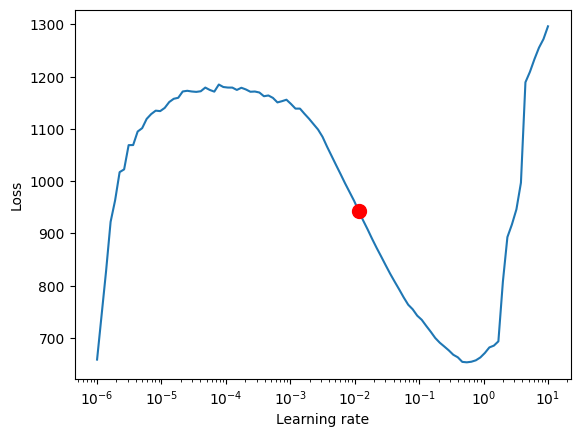

In [8]:
"""Prior to training, you can identify the optimal learning rate with the PyTorch Lightning learning rate finder."""
# Step 7, Find optimal learning rate
# configure network and trainer
pl.seed_everything(17)

trainer = pl.Trainer(
    accelerator="gpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.01,
    hidden_size=24,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=3,
    dropout=0.5,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=16,  # set to <= hidden_size
    loss=QuantileLoss(),
    optimizer="adamw",
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

# find optimal learning rate
from lightning.pytorch.tuner import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()

In [ ]:
# Step 8, Train the model
# configure the trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.1,  # clipping gradients is a hyperparameter and important to prevent divergance
    limit_train_batches=0.5,  # the number or percentage of batches used from the training set per epoch.
    # limit_val_batches=0.5,  # the number or percentage of batches used from the validation set per epoch.
    enable_checkpointing=True,  # save checkpoints
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

# configure the tft model
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.0001,  # use a small learning rate
    hidden_size=24,
    attention_head_size=3,
    dropout=0.5,  
    hidden_continuous_size=16,  # set to <= hidden_size
    loss=SMAPE(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="adamw",
    reduce_on_plateau_patience=4,
    weight_decay=0.05,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 64.0k


In [10]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | SMAPE                           | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 353    | train
3  | prescalers                         | ModuleDict                      | 512    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 4.9 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 24.8 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 3.7 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 2.4 K  | train
8  | static_context_initial_hidden_lstm |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
"""PyTorch Lightning automatically checkpoints training and thus, we can easily retrieve the best model and load it."""
from pytorch_forecasting.metrics import SMAPE

# Step 9, Evaluate the model
# load the best model according to the validation loss
# (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# calculate mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader, mode="prediction", return_x=True, trainer_kwargs=dict(accelerator="gpu")
)
print(predictions.output.shape)

# shape: (batch_size, decoder_length, num_quantiles)
median_preds = predictions.output
true_values = predictions.x["decoder_target"]  

mae = MAE()(median_preds, true_values)
print(f"MAE: {mae:.2f}")

# Calculate SMAPE on validation set
smape_value = SMAPE()(median_preds, true_values)
print(f"SMAPE: {smape_value * 100:.2f}%")  # both values are better than the baseline model.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


torch.Size([1, 15])
MAE: 210.51
SMAPE: 3.88%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


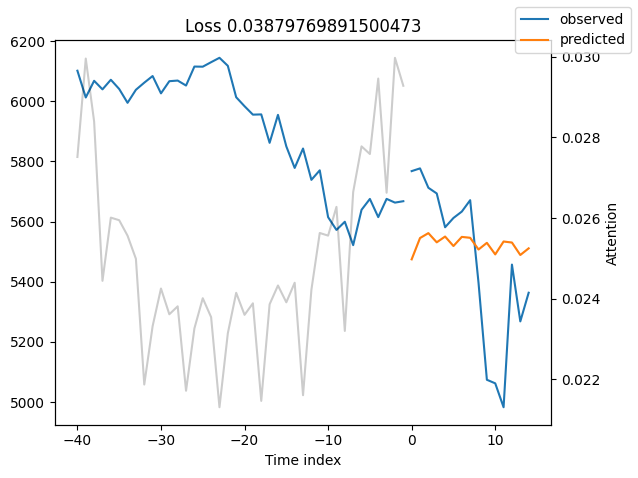

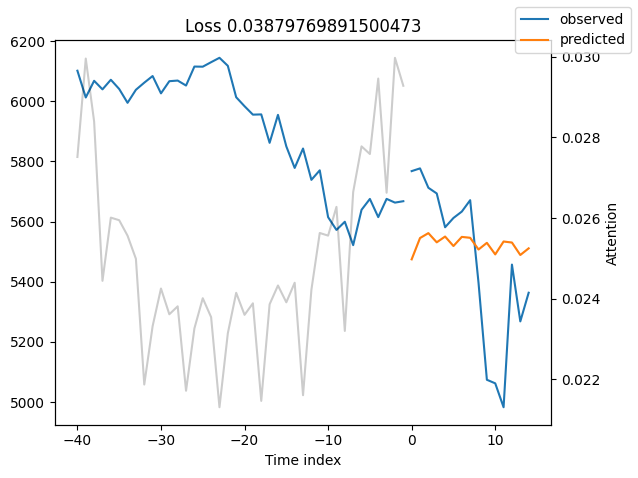

In [ ]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs={"accelerator": "gpu", "devices": 1}
)

best_tft.plot_prediction(
    raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True
    )

In [16]:
print(predictions.output[0])

tensor([5474.4067, 5545.1875, 5561.4380, 5530.9150, 5550.0625, 5518.6445,
        5548.9404, 5545.9473, 5507.0503, 5529.1738, 5490.8145, 5533.5762,
        5530.1968, 5488.8276, 5510.8496], device='cuda:0')


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x600 with 1 Axes>,
 'decoder_variables': <Figure size 700x325 with 1 Axes>}

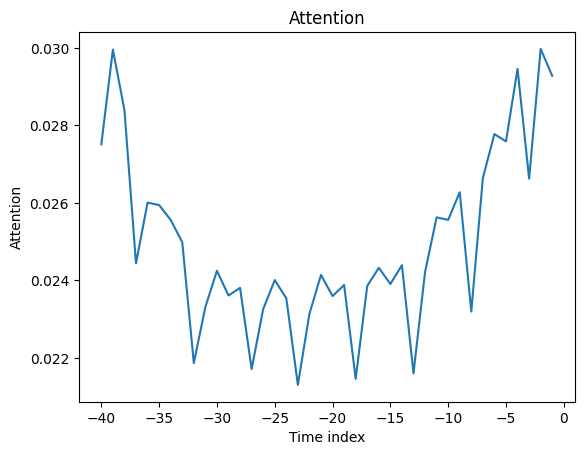

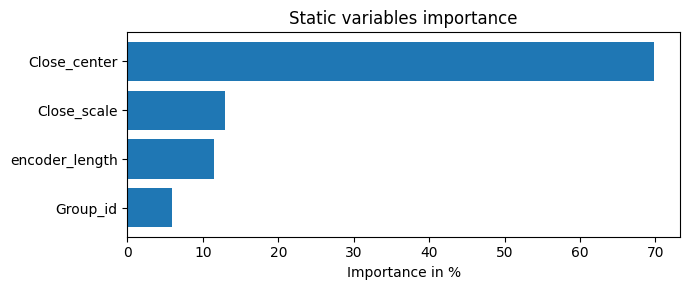

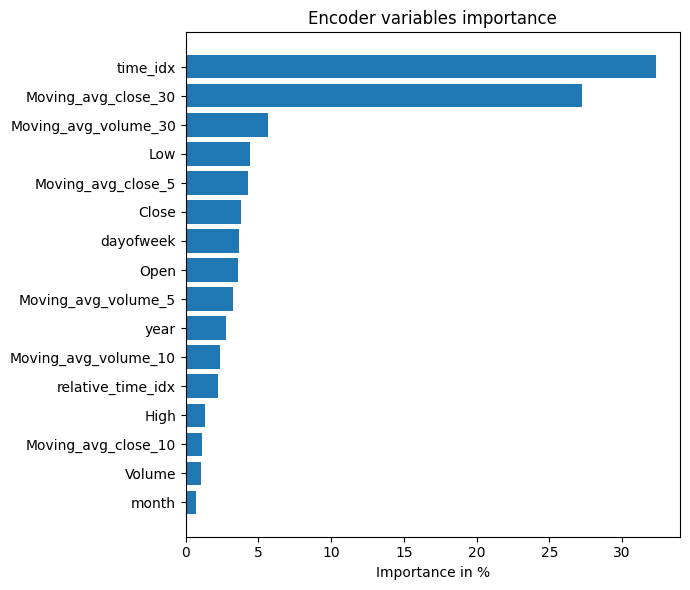

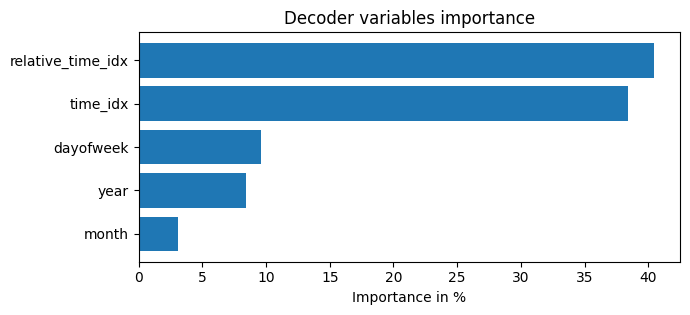

In [18]:
# Step 10, Interpret the model
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="mean")
best_tft.plot_interpretation(interpretation)